In [1]:
!pip -q install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [4]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax')])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.7685 - loss: 0.6313 - val_accuracy: 0.8560 - val_loss: 0.4108
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8550 - loss: 0.4020 - val_accuracy: 0.8768 - val_loss: 0.3418
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8727 - loss: 0.3490 - val_accuracy: 0.8863 - val_loss: 0.3165
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8829 - loss: 0.3188 - val_accuracy: 0.8875 - val_loss: 0.3055
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8919 - loss: 0.2960 - val_accuracy: 0.8965 - val_loss: 0.2854
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8987 - loss: 0.2757 - val_accuracy: 0.9018 - val_loss: 0.2728
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9045 - loss: 0.2631 - val_accuracy: 0.9022 - val_loss: 0.2688
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9095 - loss: 0.2474 - val_accuracy: 

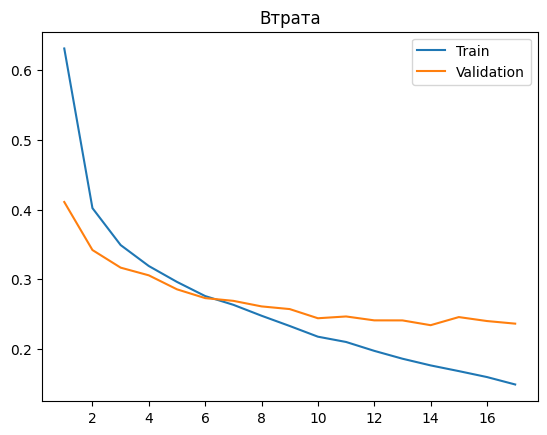

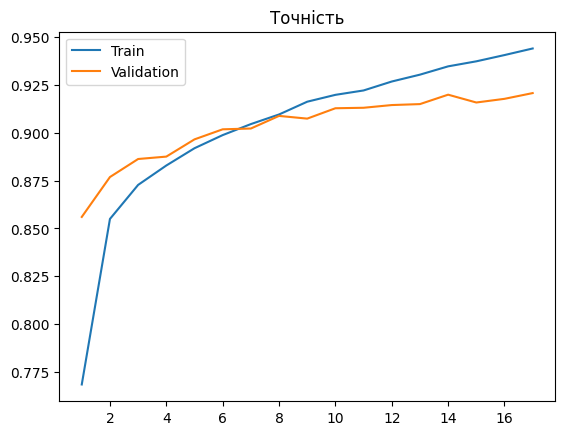

In [7]:
history_dict = history.history
epochs = range(1,len(history_dict['loss'])+1)
plt.plot(epochs,history_dict['loss'],label='Train')
plt.plot(epochs,history_dict['val_loss'],label='Validation')
plt.title("Втрата")
plt.legend()
plt.show()
plt.plot(epochs,history_dict['accuracy'],label='Train')
plt.plot(epochs,history_dict['val_accuracy'],label='Validation')
plt.title("Точність")
plt.legend()
plt.show()

In [8]:
test_loss,test_acc = model.evaluate(x_test,y_test)
print("Точність",test_acc)
print("Втрата",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9141 - loss: 0.2475
Точність 0.9140999913215637
Втрата 0.24750788509845734


2 частина VGG16

In [9]:
from keras.applications import VGG16

In [30]:
x_train_vgg = np.repeat(x_train, 3, axis=-1)
x_test_vgg = np.repeat(x_test, 3, axis=-1)
x_train_vgg = tf.image.resize(x_train_vgg, (32, 32))
x_test_vgg = tf.image.resize(x_test_vgg, (32, 32))
print(x_train_vgg.shape)
print(x_test_vgg.shape)

(60000, 32, 32, 3)
(10000, 32, 32, 3)


In [31]:
y_train_cat =y_train
y_test_cat = y_test

In [32]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

In [33]:
conv_base.trainable = False

In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [35]:
model_vgg = Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

In [36]:
model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [39]:
history = model_vgg.fit(
    x_train_vgg,
    y_train_cat,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7906 - loss: 0.6110 - val_accuracy: 0.8283 - val_loss: 0.4768
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8458 - loss: 0.4278 - val_accuracy: 0.8407 - val_loss: 0.4324
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8551 - loss: 0.3957 - val_accuracy: 0.8472 - val_loss: 0.4177
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8619 - loss: 0.3740 - val_accuracy: 0.8497 - val_loss: 0.4080
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8698 - loss: 0.3544 - val_accuracy: 0.8619 - val_loss: 0.3804
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8759 - loss: 0.3389 - val_accuracy: 0.8599 - val_loss: 0.3827
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8791 - loss: 0.3287 - val_accuracy: 0.8670 - val_loss: 0.3676
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8812 - loss: 0.3206 - 

In [40]:
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
    if layer.name == "block5_conv1":
        set_trainable = True
    layer.trainable = set_trainable

In [41]:
model_vgg.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history_fine = model_vgg.fit(
    x_train_vgg,
    y_train_cat,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.7437 - loss: 0.7297 - val_accuracy: 0.8497 - val_loss: 0.4055
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8682 - loss: 0.3679 - val_accuracy: 0.8714 - val_loss: 0.3785
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8852 - loss: 0.3218 - val_accuracy: 0.8800 - val_loss: 0.3634
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8950 - loss: 0.2898 - val_accuracy: 0.8997 - val_loss: 0.2857
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9016 - loss: 0.2719 - val_accuracy: 0.9011 - val_loss: 0.2810
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9062 - loss: 0.2605 - val_accuracy: 0.9001 - val_loss: 0.2806
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9085 - loss: 0.2519 - val_accuracy: 0.8999 - val_loss: 0.2950
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9146 - loss: 0.2398 - 

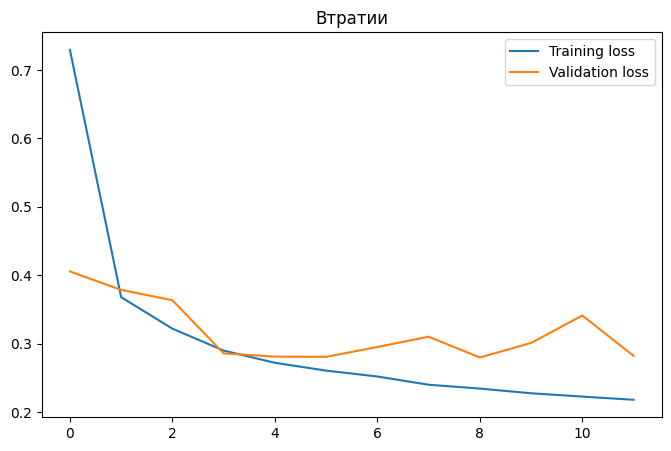

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history_fine.history['loss'], label='Training loss')
plt.plot(history_fine.history['val_loss'], label='Validation loss')
plt.title("Втратии")
plt.legend()
plt.show()

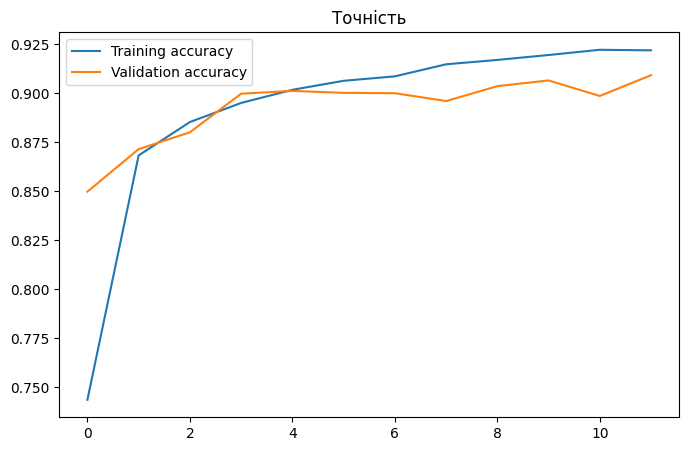

In [46]:
plt.figure(figsize=(8,5))
plt.plot(history_fine.history['accuracy'], label='Training accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation accuracy')
plt.title("Точність")
plt.legend()
plt.show()

In [47]:
test_loss, test_acc = model_vgg.evaluate(x_test_vgg,y_test_cat)
print("Точність:", test_acc)
print("Втрати:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9034 - loss: 0.2927
Точність: 0.9034000039100647
Втрати: 0.29271528124809265


In [54]:
from sklearn.metrics import classification_report
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
true_classes = np.argmax(y_test, axis=1)
predictions = model_vgg.predict(x_test_vgg)
predicted_classes = np.argmax(predictions, axis=1)
print(classification_report(true_classes,predicted_classes,target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.80      0.88      0.84      1000
       Dress       0.86      0.93      0.89      1000
        Coat       0.87      0.80      0.83      1000
      Sandal       0.99      0.96      0.98      1000
       Shirt       0.77      0.69      0.73      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.98      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

